In [1]:
# Ячейка 1: Настройка путей
import os
import sys
from pathlib import Path

# Находим корень проекта (родительская папка notebooks/)
PROJECT_ROOT = Path(os.getcwd()).parent
print(f"📍 Корень проекта: {PROJECT_ROOT}")

# Пути к данным
NYU_TRAIN_DIR = PROJECT_ROOT / "data" / "raw" / "train-000000" 
NYU_VAL_DIR = PROJECT_ROOT / "data" / "raw" / "val" / "official"
DIODE_FILE = PROJECT_ROOT / "data" / "diode_hdf5" / "diode_train.hdf5"

print(f"📂 NYU Train: {NYU_TRAIN_DIR}")
print(f" NYU Val: {NYU_VAL_DIR}")
print(f"📂 DIODE: {DIODE_FILE}")

📍 Корень проекта: c:\Users\Redmi\Depth-From-Focus-Image-Restoring
📂 NYU Train: c:\Users\Redmi\Depth-From-Focus-Image-Restoring\data\raw\train-000000
 NYU Val: c:\Users\Redmi\Depth-From-Focus-Image-Restoring\data\raw\val\official
📂 DIODE: c:\Users\Redmi\Depth-From-Focus-Image-Restoring\data\diode_hdf5\diode_train.hdf5


In [2]:
import h5py
import matplotlib.pyplot as plt
import glob

print("\n" + "="*40)
print("СТАТИСТИКА")
print("="*40)

train_files = glob.glob(str(NYU_TRAIN_DIR) + "/**/*.h5", recursive=True)
val_files = glob.glob(str(NYU_VAL_DIR) + "/**/*.h5", recursive=True)

print(f" NYU Train: {len(train_files)} файлов")
print(f" NYU Val: {len(val_files)} файлов")

if DIODE_FILE.exists():
    with h5py.File(str(DIODE_FILE), 'r') as f:
        diode_count = len(f.keys())
    print(f" DIODE: {diode_count} изображений")
else:
    print(f" DIODE не найден: {DIODE_FILE}")



СТАТИСТИКА
 NYU Train: 2193 файлов
 NYU Val: 645 файлов
 DIODE: 1255 изображений


NYU файл: 00001.h5


NameError: name 'np' is not defined

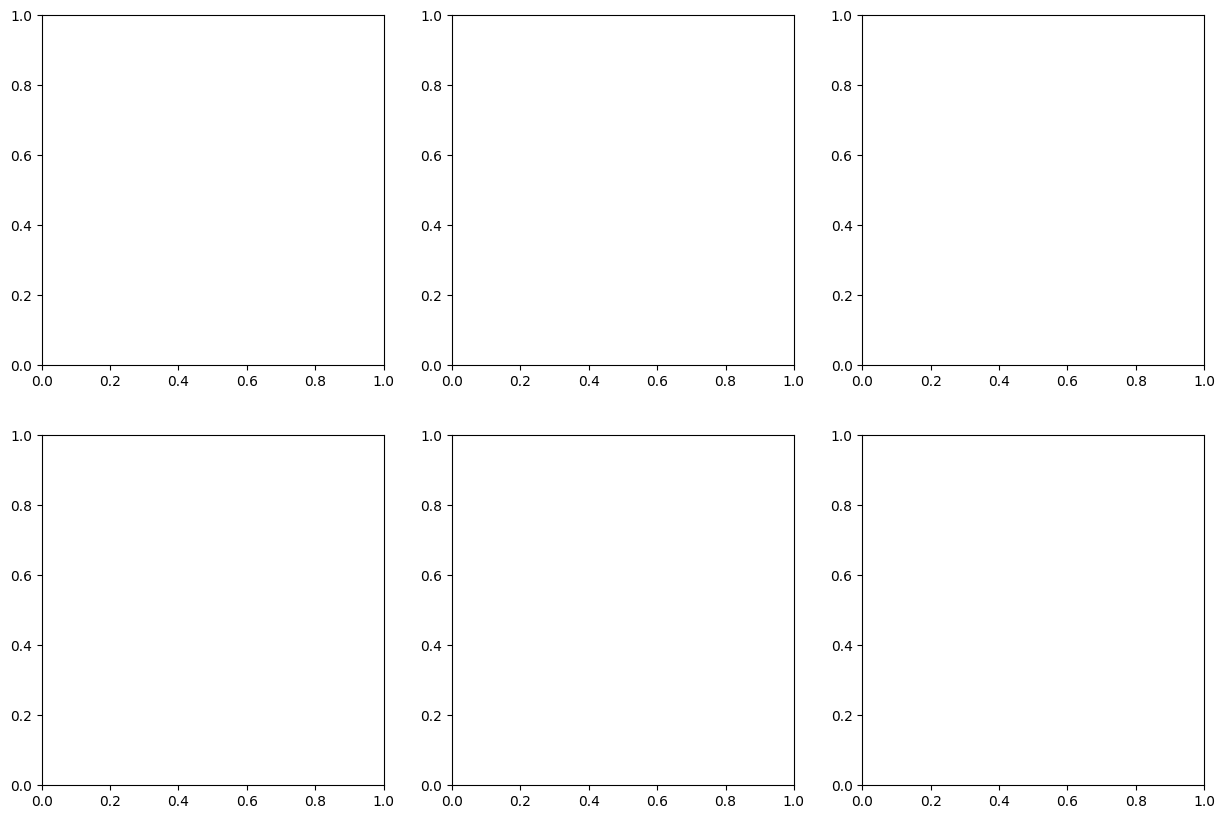

In [3]:
import glob

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

def get_first_file(directory):
    files = glob.glob(str(directory) + "/**/*.h5", recursive=True)
    return files[0] if files else None

# NYU пример
nyu_file = get_first_file(NYU_TRAIN_DIR)
if nyu_file:
    print(f"NYU файл: {Path(nyu_file).name}")
    with h5py.File(nyu_file, 'r') as f:
        rgb = f['rgb'][:]
        depth = f['depth'][:]
    
    if rgb.ndim == 3 and rgb.shape[0] == 3:
        rgb = np.transpose(rgb, (1, 2, 0))
    
    axes[0, 0].imshow(rgb)
    axes[0, 0].set_title(f"NYU RGB\n{Path(nyu_file).name}")
    axes[0, 1].imshow(depth, cmap='magma')
    axes[0, 1].set_title(f"NYU Depth\nRange: {depth.min():.2f} - {depth.max():.2f}m")
    axes[0, 2].axis('off')
    axes[0, 2].text(0.5, 0.5, f"RGB: {rgb.shape}\nDepth: {depth.shape}", 
                    ha='center', va='center', fontsize=10)
else:
    axes[0, 0].text(0.5, 0.5, "NYU files not found", ha='center', va='center')
    axes[0, 0].axis('off')

if DIODE_FILE.exists():
    print(f"DIODE файл: {DIODE_FILE.name}")
    with h5py.File(str(DIODE_FILE), 'r') as f:
        group = f['sample_000000']
        rgb = group['rgb'][:]
        depth = group['depth'][:]
    
    if rgb.ndim == 3 and rgb.shape[0] == 3:
        rgb = np.transpose(rgb, (1, 2, 0))
    
    axes[1, 0].imshow(rgb)
    axes[1, 0].set_title("DIODE RGB")
    axes[1, 1].imshow(depth, cmap='magma')
    axes[1, 1].set_title(f"DIODE Depth\nRange: {depth.min():.2f} - {depth.max():.2f}m")
    axes[1, 2].axis('off')
    axes[1, 2].text(0.5, 0.5, f"RGB: {rgb.shape}\nDepth: {depth.shape}", 
                    ha='center', va='center', fontsize=10)
else:
    axes[1, 0].text(0.5, 0.5, "DIODE not found", ha='center', va='center')
    axes[1, 0].axis('off')

plt.tight_layout()
os.makedirs("notebooks/outputs", exist_ok=True)
plt.savefig("notebooks/outputs/eda_examples.png", dpi=150)
plt.show()
print(f"\n Сохранено в notebooks/outputs/eda_examples.png")

 Распределение значений глубины

 Обрабатываем NYU...
   Берём 200 файлов
    NYU: 59471171 валидных пикселей

 Обрабатываем DIODE...
   Берём 200 образцов
    DIODE: 100128308 валидных пикселей


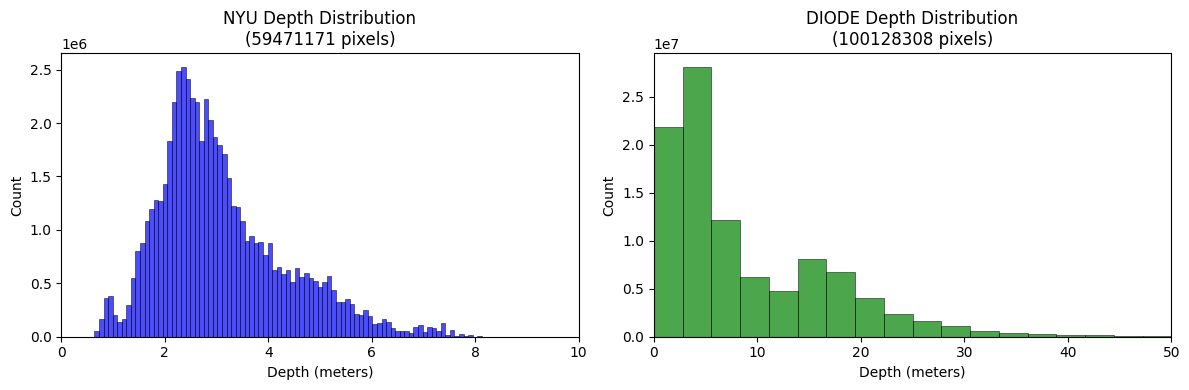


 Сохранено в notebooks/outputs/eda_depth_distribution.png


In [4]:
# Ячейка 4: Распределение глубины
import numpy as np

print(" Распределение значений глубины")
print("=" * 40)

depths_nyu = []
depths_diode = []

# Собираем статистику по NYU (первые 100 файлов)
print("\n Обрабатываем NYU...")
nyu_files_to_process = train_files[:100] if len(train_files) > 0 else []
print(f"   Берём {len(nyu_files_to_process)} файлов")

for h5_file in nyu_files_to_process:
    try:
        with h5py.File(h5_file, 'r') as f:
            depth = f['depth'][:]
            valid_depth = depth[depth > 0]
            if len(valid_depth) > 0:
                depths_nyu.extend(valid_depth.flatten().tolist())
    except Exception as e:
        print(f"   ️ Ошибка с {h5_file}: {e}")

print(f"    NYU: {len(depths_nyu)} валидных пикселей")

# DIODE
if DIODE_FILE.exists():
    print(f"\n Обрабатываем DIODE...")
    try:
        with h5py.File(str(DIODE_FILE), 'r') as f:
            num_samples = min(100, len(f.keys()))
            print(f"   Берём {num_samples} образцов")
            for i in range(num_samples):
                group = f[f'sample_{i:06d}']
                depth = group['depth'][:]
                valid_depth = depth[depth > 0]
                if len(valid_depth) > 0:
                    depths_diode.extend(valid_depth.flatten().tolist())
        print(f"    DIODE: {len(depths_diode)} валидных пикселей")
    except Exception as e:
        print(f"    Ошибка с DIODE: {e}")
else:
    print(f"\n DIODE не найден, пропускаем")

# Гистограмма
if depths_nyu or depths_diode:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    if depths_nyu:
        axes[0].hist(depths_nyu, bins=100, alpha=0.7, color='blue', edgecolor='black', linewidth=0.5)
        axes[0].set_title(f"NYU Depth Distribution\n({len(depths_nyu)} pixels)")
        axes[0].set_xlabel("Depth (meters)")
        axes[0].set_ylabel("Count")
        axes[0].set_xlim(0, 10)  # Ограничим для наглядности
    else:
        axes[0].text(0.5, 0.5, "No NYU data", ha='center', va='center')
        axes[0].axis('off')
    
    if depths_diode:
        axes[1].hist(depths_diode, bins=100, alpha=0.7, color='green', edgecolor='black', linewidth=0.5)
        axes[1].set_title(f"DIODE Depth Distribution\n({len(depths_diode)} pixels)")
        axes[1].set_xlabel("Depth (meters)")
        axes[1].set_ylabel("Count")
        axes[1].set_xlim(0, 50)
    else:
        axes[1].text(0.5, 0.5, "No DIODE data", ha='center', va='center')
        axes[1].axis('off')
    
    plt.tight_layout()
    os.makedirs("notebooks/outputs", exist_ok=True)
    plt.savefig("notebooks/outputs/eda_depth_distribution.png", dpi=150)
    plt.show()
    print(f"\n Сохранено в notebooks/outputs/eda_depth_distribution.png")
else:
    print("\n Нет данных для отображения")